# Topology validation: pykarambola vs C++ karambola

Validates numerical agreement on three pure-NumPy synthetic meshes that cover
topological cases not present in the benchmarks available in Biorxiv version.

| Shape | χ | Topology |
|---|---|---|
| Torus | 0 | genus 1 — one handle/tunnel |
| Holey slab | −2 | genus 2 — rectangular box with two through-holes |
| Hollow shell | 4 | two nested icospheres — enclosed void (2-2g+2c, where c=cavities ) |

Each shape is tested at several mesh resolutions.
Meshes are generated in **Section 1** (pure NumPy).
Run C++ karambola on the `.off` files before executing **Section 3**.

**Workflow**
```
Section 1 — generate .off files    (run once, then comment out or re-run to regenerate)
Section 2 — run pykarambola        (no external data needed)
Section 3 — parse karambola        (requires karambola run on the .off files)
Section 4 — accuracy comparison    (requires Sections 2 and 3)
```

## Environment

In [1]:
import os
import re
import glob
import platform
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import pykarambola

In [2]:
print(f"pykarambola version : {pykarambola.__version__}")
print(f"Python              : {platform.python_version()}")
print(f"OS                  : {platform.system()} {platform.release()}")
print(f"Machine             : {platform.machine()}")
try:
    chip = subprocess.run(
        ['sysctl', '-n', 'machdep.cpu.brand_string'],
        capture_output=True, text=True
    ).stdout.strip() or platform.processor()
except Exception:
    chip = platform.processor()
print(f"Chip                : {chip}")
print(f"Logical cores       : {os.cpu_count()}")

pykarambola version : 0.5.0
Python              : 3.11.13
OS                  : Darwin 24.6.0
Machine             : x86_64
Chip                : Apple M1 Pro
Logical cores       : 10


## Configuration

In [3]:
REPO_ROOT   = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
MESH_DIR    = os.path.join(REPO_ROOT, 'dataset', 'topology_validation')
KARA_DIR    = os.path.join(REPO_ROOT, 'dataset', 'karambola_results', 'topology_validation')
RESULTS_DIR = os.path.join(os.getcwd(), 'results')

os.makedirs(RESULTS_DIR, exist_ok=True)

SCALAR_KEYS = ['w000', 'w100', 'w200', 'w300']
VECTOR_KEYS = ['w010', 'w110', 'w210', 'w310']
TENSOR_KEYS = ['w020', 'w120', 'w220', 'w320', 'w102', 'w202']

# Shape parameters — 5 resolutions per shape (coarse → fine)
TORUS_PARAMS        = dict(R=3.0, r=1.0)
TORUS_RESOLUTIONS   = [16, 48, 64, 96, 128]      # n (segments in u and v)

SLAB_PARAMS         = dict(width=6.0, depth=4.0, height=1.5,
                           hole_w=1.0, hole_d=2.0, spacing=3.0)
SLAB_RESOLUTIONS    = [2, 4, 8, 16, 32]           # n (grid subdivisions per structural interval)

SHELL_PARAMS        = dict(R_outer=2.0, R_inner=1.0)
SHELL_RESOLUTIONS   = [3, 4, 5, 6, 7]             # icosphere subdivision level

SHAPES = ['torus', 'holey_slab', 'hollow_shell']

print(f"Mesh dir    : {MESH_DIR}")
print(f"Karambola   : {KARA_DIR}")
print(f"Results dir : {RESULTS_DIR}")

Mesh dir    : /Users/yk/Desktop/pykarambola_m1/pykarambola/dataset/topology_validation
Karambola   : /Users/yk/Desktop/pykarambola_m1/pykarambola/dataset/karambola_results/topology_validation
Results dir : /Users/yk/Desktop/pykarambola_m1/pykarambola/paper/notebooks/results


## Helper functions

In [4]:
# ── Mesh primitives ───────────────────────────────────────────────────────────

def icosphere(subdivisions, radius=1.0):
    """Pure-NumPy icosphere (internal helper for hollow_shell)."""
    phi = (1.0 + np.sqrt(5.0)) / 2.0
    base_verts = np.array([
        [-1, phi, 0], [1, phi, 0], [-1, -phi, 0], [1, -phi, 0],
        [0, -1, phi], [0, 1, phi], [0, -1, -phi], [0, 1, -phi],
        [phi, 0, -1], [phi, 0, 1], [-phi, 0, -1], [-phi, 0, 1],
    ], dtype=np.float64)
    base_verts /= np.linalg.norm(base_verts[0])
    faces = [
        [0,11,5],[0,5,1],[0,1,7],[0,7,10],[0,10,11],
        [1,5,9],[5,11,4],[11,10,2],[10,7,6],[7,1,8],
        [3,9,4],[3,4,2],[3,2,6],[3,6,8],[3,8,9],
        [4,9,5],[2,4,11],[6,2,10],[8,6,7],[9,8,1],
    ]
    verts_list = list(base_verts)
    def midpoint(a, b, cache):
        key = (min(a, b), max(a, b))
        if key not in cache:
            m = (verts_list[a] + verts_list[b]) * 0.5
            cache[key] = len(verts_list)
            verts_list.append(m / np.linalg.norm(m))
        return cache[key]
    for _ in range(subdivisions):
        cache, new_faces = {}, []
        for tri in faces:
            a, b, c = tri
            ab, bc, ca = midpoint(a,b,cache), midpoint(b,c,cache), midpoint(c,a,cache)
            new_faces += [[a,ab,ca],[b,bc,ab],[c,ca,bc],[ab,bc,ca]]
        faces = new_faces
    return np.array(verts_list, dtype=np.float64) * radius, np.array(faces, dtype=np.int64)


def torus(R, r, n):
    """Closed parametric torus.  χ = 0 (genus 1)."""
    u = np.linspace(0, 2*np.pi, n, endpoint=False)
    v = np.linspace(0, 2*np.pi, n, endpoint=False)
    U, V = np.meshgrid(u, v, indexing='ij')
    X = (R + r * np.cos(V)) * np.cos(U)
    Y = (R + r * np.cos(V)) * np.sin(U)
    Z = r * np.sin(V)
    verts = np.stack([X.ravel(), Y.ravel(), Z.ravel()], axis=1)

    I, J = np.meshgrid(np.arange(n), np.arange(n), indexing='ij')
    I, J = I.ravel(), J.ravel()
    p00 = I * n + J
    p10 = ((I+1) % n) * n + J
    p01 = I * n + (J+1) % n
    p11 = ((I+1) % n) * n + (J+1) % n
    faces = np.vstack([
        np.stack([p00, p10, p11], axis=1),
        np.stack([p00, p11, p01], axis=1),
    ]).astype(np.int64)
    return verts, faces


def holey_slab(width, depth, height, hole_w, hole_d, spacing, n=4):
    """
    Closed rectangular slab with two rectangular through-holes (tunnels along z).
    χ = −2  (genus 2).  All faces are flat — no trigonometry needed.

    Parameters
    ----------
    width, depth, height : outer slab dimensions (x, y, z)
    hole_w, hole_d       : hole size along x and y
    spacing              : centre-to-centre distance between the two holes (along x)
    n                    : grid subdivisions per structural interval
    """
    W, D, H = width, depth, height
    hw, hd  = hole_w, hole_d
    S       = spacing

    xs_bp = np.array([-W/2, -S/2 - hw/2, -S/2 + hw/2,
                             S/2 - hw/2,   S/2 + hw/2,  W/2])
    ys_bp = np.array([-D/2, -hd/2, hd/2, D/2])
    zs    = np.linspace(0.0, H, n + 1)

    def refine(bp):
        segs = [np.linspace(bp[i], bp[i+1], n + 1) for i in range(len(bp) - 1)]
        return np.concatenate([segs[0]] + [s[1:] for s in segs[1:]])

    xs = refine(xs_bp)   # 5n+1 points
    ys = refine(ys_bp)   # 3n+1 points
    nxi, nyi = len(xs) - 1, len(ys) - 1

    def is_hole(ix, iy):
        """Cell (ix,iy) falls inside one of the two hole rectangles."""
        in_y = n <= iy < 2 * n
        in_x = (n <= ix < 2 * n) or (3 * n <= ix < 4 * n)
        return in_y and in_x

    verts_list = []
    faces_list = []

    def addv(x, y, z):
        verts_list.append([float(x), float(y), float(z)])
        return len(verts_list) - 1

    def quad(a, b, c, d):
        faces_list.extend([[a, b, c], [a, c, d]])

    # ── Top (z=H, normal +z) and bottom (z=0, normal −z) faces ───────────────
    # Vertices are created on-demand to avoid isolated interior hole vertices
    # (which would corrupt the Euler characteristic).
    for z, top in [(0.0, False), (H, True)]:
        g = {}
        def gv(ix, iy, _z=z):
            if (ix, iy) not in g:
                g[(ix, iy)] = addv(xs[ix], ys[iy], _z)
            return g[(ix, iy)]
        for iy in range(nyi):
            for ix in range(nxi):
                if is_hole(ix, iy):
                    continue
                a, b, c, d = gv(ix, iy), gv(ix+1, iy), gv(ix+1, iy+1), gv(ix, iy+1)
                quad(a, b, c, d) if top else quad(a, d, c, b)

    # ── Outer side walls ──────────────────────────────────────────────────────
    for iz in range(n):
        z0, z1 = zs[iz], zs[iz + 1]
        for ix in range(nxi):                          # front (y=−D/2, normal −y)
            quad(addv(xs[ix],   -D/2, z0), addv(xs[ix+1], -D/2, z0),
                 addv(xs[ix+1], -D/2, z1), addv(xs[ix],   -D/2, z1))
        for ix in range(nxi):                          # back  (y=+D/2, normal +y)
            quad(addv(xs[ix+1],  D/2, z0), addv(xs[ix],    D/2, z0),
                 addv(xs[ix],    D/2, z1), addv(xs[ix+1],  D/2, z1))
        for iy in range(nyi):                          # left  (x=−W/2, normal −x)
            quad(addv(-W/2, ys[iy+1], z0), addv(-W/2, ys[iy],   z0),
                 addv(-W/2, ys[iy],   z1), addv(-W/2, ys[iy+1], z1))
        for iy in range(nyi):                          # right (x=+W/2, normal +x)
            quad(addv( W/2, ys[iy],   z0), addv( W/2, ys[iy+1], z0),
                 addv( W/2, ys[iy+1], z1), addv( W/2, ys[iy],   z1))

    # ── Tunnel walls (normals point inward toward tunnel axis) ────────────────
    for cx in [-S/2, S/2]:
        xl, xr  = cx - hw/2, cx + hw/2
        yf, yb  = -hd/2,  hd/2
        xs_t = np.linspace(xl, xr, n + 1)
        ys_t = np.linspace(yf, yb, n + 1)
        for iz in range(n):
            z0, z1 = zs[iz], zs[iz + 1]
            for ix in range(n):                        # front tunnel (y=yf, normal +y)
                quad(addv(xs_t[ix+1], yf, z0), addv(xs_t[ix],   yf, z0),
                     addv(xs_t[ix],   yf, z1), addv(xs_t[ix+1], yf, z1))
            for ix in range(n):                        # back  tunnel (y=yb, normal −y)
                quad(addv(xs_t[ix],   yb, z0), addv(xs_t[ix+1], yb, z0),
                     addv(xs_t[ix+1], yb, z1), addv(xs_t[ix],   yb, z1))
            for iy in range(n):                        # left  tunnel (x=xl, normal +x)
                quad(addv(xl, ys_t[iy],   z0), addv(xl, ys_t[iy+1], z0),
                     addv(xl, ys_t[iy+1], z1), addv(xl, ys_t[iy],   z1))
            for iy in range(n):                        # right tunnel (x=xr, normal −x)
                quad(addv(xr, ys_t[iy+1], z0), addv(xr, ys_t[iy],   z0),
                     addv(xr, ys_t[iy],   z1), addv(xr, ys_t[iy+1], z1))

    # ── Merge duplicate vertices ──────────────────────────────────────────────
    V = np.array(verts_list, dtype=np.float64)
    F = np.array(faces_list, dtype=np.int64)
    uniq, inv = np.unique(np.round(V, 10), axis=0, return_inverse=True)
    return uniq, inv[F]


def hollow_shell(R_outer, R_inner, subdivisions):
    """Two nested icospheres representing a true hollow shell.  χ = 4."""
    v_out, f_out = icosphere(subdivisions, R_outer)
    v_in,  f_in  = icosphere(subdivisions, R_inner)
    N = len(v_out)
    f_in_flipped = f_in[:, [0, 2, 1]]
    return np.vstack([v_out, v_in]), np.vstack([f_out, f_in_flipped + N])


def write_off(filepath, verts, faces):
    """Write a triangulated mesh to an .off file."""
    os.makedirs(os.path.dirname(filepath), exist_ok=True)
    with open(filepath, 'w') as fh:
        fh.write('OFF\n')
        fh.write(f'{len(verts)} {len(faces)} 0\n')
        for v in verts:
            fh.write(f'{v[0]:.10f} {v[1]:.10f} {v[2]:.10f}\n')
        for f in faces:
            fh.write(f'3 {f[0]} {f[1]} {f[2]}\n')

In [5]:
# ── Mesh validation ───────────────────────────────────────────────────────────

def euler_characteristic(verts, faces):
    """Compute χ = V − E + F via unique-edge counting."""
    V = len(verts)
    F = len(faces)
    edges = np.sort(np.concatenate([
        faces[:, [0, 1]], faces[:, [1, 2]], faces[:, [2, 0]],
    ], axis=0), axis=1)
    E = len(np.unique(edges, axis=0))
    return V - E + F


def edge_valence(faces):
    """Return a dict: valence → count of edges with that many adjacent faces.
    A closed manifold should have only valence-2 edges.
    """
    edges = np.sort(np.concatenate([
        faces[:, [0, 1]], faces[:, [1, 2]], faces[:, [2, 0]],
    ], axis=0), axis=1)
    _, counts = np.unique(edges, axis=0, return_counts=True)
    unique, freq = np.unique(counts, return_counts=True)
    return dict(zip(unique.tolist(), freq.tolist()))

In [6]:
# ── karambola output parsers (matching benchmark_adrenal3d.ipynb) ─────────────

def _safe_float(s):
    """Return float(s) or NaN if s is not a valid number (e.g. 'ERROR')."""
    try:
        return float(s)
    except ValueError:
        return float('nan')


def drop_symmetric_duplicates(df):
    """Drop redundant off-diagonal symmetric columns (e.g. w020_10 when w020_01 == w020_10)."""
    pattern = re.compile(r'^(w\d{3})_(\d)(\d)$')
    seen, to_drop = set(), []
    for col in df.columns:
        m = pattern.match(col)
        if m:
            tensor, i, j = m.groups()
            sym = f'{tensor}_{j}{i}'
            if i != j and sym in df.columns and (col, sym) not in seen and (sym, col) not in seen:
                seen.add((col, sym))
                if (df[col] == df[sym]).all():
                    to_drop.append(sym)
    return df.drop(columns=to_drop)


def parse_karambola_folder(folder_path):
    """Read all standard karambola output files from one mesh result folder.
    Returns a flat dict (scalar, vector, tensor, eigval, MSM entries).
    Non-numeric values (e.g. 'ERROR') are stored as NaN.
    """
    data = {k: None for k in SCALAR_KEYS}
    for k in VECTOR_KEYS:
        data[k] = [None] * 3
    for k in TENSOR_KEYS:
        data[k] = [[None]*3 for _ in range(3)]
        data[f'{k}_eig'] = [None] * 3
    data['msm_ql'] = [float('nan')] * 9
    data['msm_wl'] = [float('nan')] * 9

    fp = os.path.join(folder_path, 'w000_w100_w200_w300')
    if os.path.exists(fp):
        with open(fp) as f:
            for line in f:
                if line.startswith('#') or not line.strip(): continue
                cols = line.split()
                if len(cols) >= 3 and cols[2] in data:
                    data[cols[2]] = _safe_float(cols[1])

    fp = os.path.join(folder_path, 'w010_w110_w210_w310')
    if os.path.exists(fp):
        with open(fp) as f:
            for line in f:
                if line.startswith('#') or not line.strip(): continue
                cols = line.split()
                if len(cols) >= 5 and cols[4] in data:
                    data[cols[4]] = [_safe_float(cols[1]),
                                     _safe_float(cols[2]),
                                     _safe_float(cols[3])]

    for t in TENSOR_KEYS:
        fp = os.path.join(folder_path, t)
        if os.path.exists(fp):
            with open(fp) as f:
                for line in f:
                    if line.startswith('#') or not line.strip(): continue
                    cols = line.split()
                    if len(cols) >= 11 and cols[10] == t:
                        data[t] = [
                            [_safe_float(cols[1]), _safe_float(cols[2]), _safe_float(cols[3])],
                            [_safe_float(cols[4]), _safe_float(cols[5]), _safe_float(cols[6])],
                            [_safe_float(cols[7]), _safe_float(cols[8]), _safe_float(cols[9])],
                        ]

    for t in TENSOR_KEYS:
        fp = os.path.join(folder_path, f'{t}_eigsys')
        if os.path.exists(fp):
            with open(fp) as f:
                for line in f:
                    if line.startswith('#') or not line.strip(): continue
                    if 'ALL' not in line: continue
                    parts = line.split()
                    data[f'{t}_eig'] = sorted([
                        _safe_float(parts[1]),
                        _safe_float(parts[5]),
                        _safe_float(parts[9])
                    ])

    fp = os.path.join(folder_path, 'msm_ql')
    if os.path.exists(fp):
        with open(fp) as f:
            for line in f:
                if line.startswith('#') or not line.strip(): continue
                if 'ALL' not in line: continue
                cols = line.split()
                data['msm_ql'] = [_safe_float(cols[i]) for i in range(1, 18, 2)]
                data['msm_wl'] = [_safe_float(cols[i]) for i in range(2, 19, 2)]

    return data


def build_row(data, mesh_id, shape):
    """Flatten a parse_karambola_folder result dict into a record dict."""
    row = {'mesh_id': mesh_id, 'shape': shape}
    for k in SCALAR_KEYS:
        row[k] = data[k]
    for k in VECTOR_KEYS:
        for i in range(3):
            row[f'{k}_{i}'] = data[k][i]
    for k in TENSOR_KEYS:
        for i in range(3):
            for j in range(3):
                row[f'{k}_{i}{j}'] = data[k][i][j]
        for n, ev in enumerate(data[f'{k}_eig'], 1):
            row[f'{k}_EVal{n}'] = ev
    for n, v in enumerate(data['msm_ql']):
        row[f'msm_ql_{n}'] = v
    for n, v in enumerate(data['msm_wl']):
        row[f'msm_wl_{n}'] = v
    return row


print('Helpers defined.')

Helpers defined.


---
## Section 1 — Mesh generation

Generates `.off` files for all three shapes at each resolution.
Each mesh is validated: χ is printed and checked against the expected value.

The generated files are written to `dataset/topology_validation/`.
**Re-run to regenerate; comment out once files exist and you do not want to overwrite.**

In [7]:
# ── Torus ─────────────────────────────────────────────────────────────────────
R, r = TORUS_PARAMS['R'], TORUS_PARAMS['r']
out_dir = os.path.join(MESH_DIR, 'torus')
os.makedirs(out_dir, exist_ok=True)

print(f'Torus  R={R}  r={r}')
for n in TORUS_RESOLUTIONS:
    verts, faces = torus(R, r, n)
    chi = euler_characteristic(verts, faces)
    val = edge_valence(faces)
    name = f'torus_R{R}_r{r}_n{n:03d}'
    path = os.path.join(out_dir, f'{name}.off')
    write_off(path, verts, faces)
    status = '✓' if chi == 0 and val == {2: 3*n*n} else f'WARN χ={chi} valence={val}'
    print(f'  n={n:3d} | V={len(verts):6,} F={len(faces):7,} χ={chi:+d}  {status}')

Torus  R=3.0  r=1.0
  n= 16 | V=   256 F=    512 χ=+0  ✓
  n= 48 | V= 2,304 F=  4,608 χ=+0  ✓
  n= 64 | V= 4,096 F=  8,192 χ=+0  ✓
  n= 96 | V= 9,216 F= 18,432 χ=+0  ✓
  n=128 | V=16,384 F= 32,768 χ=+0  ✓


In [8]:
# ── Holey slab ────────────────────────────────────────────────────────────────
out_dir = os.path.join(MESH_DIR, 'holey_slab')
os.makedirs(out_dir, exist_ok=True)

print(f'Holey slab  {SLAB_PARAMS}')
for n in SLAB_RESOLUTIONS:
    verts, faces = holey_slab(**SLAB_PARAMS, n=n)
    chi = euler_characteristic(verts, faces)
    val = edge_valence(faces)
    name = f'holey_slab_W{SLAB_PARAMS["width"]}_D{SLAB_PARAMS["depth"]}_H{SLAB_PARAMS["height"]}_n{n:03d}'
    path = os.path.join(out_dir, f'{name}.off')
    write_off(path, verts, faces)
    manifold_ok = set(val.keys()) == {2}
    status = '✓' if chi == -2 and manifold_ok else f'WARN χ={chi} valence={val}'
    print(f'  n={n:3d} | V={len(verts):6,} F={len(faces):7,} χ={chi:+d}  {status}')

Holey slab  {'width': 6.0, 'depth': 4.0, 'height': 1.5, 'hole_w': 1.0, 'hole_d': 2.0, 'spacing': 3.0}
  n=  2 | V=   198 F=    400 χ=-2  ✓
  n=  4 | V=   798 F=  1,600 χ=-2  ✓
  n=  8 | V= 3,198 F=  6,400 χ=-2  ✓
  n= 16 | V=12,798 F= 25,600 χ=-2  ✓
  n= 32 | V=51,198 F=102,400 χ=-2  ✓


In [9]:
# ── Hollow shell ──────────────────────────────────────────────────────────────
R_out, R_in = SHELL_PARAMS['R_outer'], SHELL_PARAMS['R_inner']
out_dir = os.path.join(MESH_DIR, 'hollow_shell')
os.makedirs(out_dir, exist_ok=True)

print(f'Hollow shell  R_outer={R_out}  R_inner={R_in}')
for sub in SHELL_RESOLUTIONS:
    verts, faces = hollow_shell(R_out, R_in, sub)
    chi = euler_characteristic(verts, faces)
    name = f'hollow_shell_Rout{R_out}_Rin{R_in}_sub{sub}'
    path = os.path.join(out_dir, f'{name}.off')
    write_off(path, verts, faces)
    status = '✓' if chi == 4 else f'WARN χ={chi}'
    print(f'  sub={sub} | V={len(verts):6,} F={len(faces):7,} χ={chi:+d}  {status}')

Hollow shell  R_outer=2.0  R_inner=1.0
  sub=3 | V= 1,284 F=  2,560 χ=+4  ✓
  sub=4 | V= 5,124 F= 10,240 χ=+4  ✓
  sub=5 | V=20,484 F= 40,960 χ=+4  ✓
  sub=6 | V=81,924 F=163,840 χ=+4  ✓
  sub=7 | V=327,684 F=655,360 χ=+4  ✓


In [92]:
import pyvista as pv
import numpy as np

SHAPE_SNAPSHOTS = {}

VIEWS = {
    'torus':        'iso',                                  
    'holey_slab':   'xy',
    'hollow_shell': 'iso',   # + clip in the mesh step
}

def save_snapshot(verts, faces, name, res=(700, 700)):
    path = os.path.join(RESULTS_DIR, f'snapshot_{name}.png')
    f = np.hstack([np.full((len(faces), 1), 3), faces]).ravel()
    mesh = pv.PolyData(verts, f)
    p = pv.Plotter(off_screen=True, window_size=list(res))
    if name == 'hollow_shell':
        p.add_mesh(mesh, color='#0072B2', opacity=0.45, smooth_shading=True, show_edges=False)                 # cutaway so the cavity shows
    else:
        p.add_mesh(mesh, color='#0072B2', smooth_shading=True, show_edges=False)
    p.camera_position = VIEWS.get(name, 'iso')
    p.screenshot(os.path.join(RESULTS_DIR, f'snapshot_{name}.png'))
    p.close()
    return path

In [93]:
# TEMPORARY — visualise torus + sanity check (remove before final run)
import trimesh

_v, _f = torus(**TORUS_PARAMS, n=48)
_m = trimesh.Trimesh(vertices=_v, faces=_f, process=False)
print(f"torus        | watertight={_m.is_watertight}  volume={_m.is_volume}  χ={euler_characteristic(_v,_f)}")
_m.show(title='torus')
SHAPE_SNAPSHOTS['torus'] = save_snapshot(_v, _f, 'torus')

torus        | watertight=True  volume=True  χ=0


In [94]:
_v, _f = holey_slab(**SLAB_PARAMS, n=4)
_m = trimesh.Trimesh(vertices=_v, faces=_f, process=False)
print(f"holey slab | watertight={_m.is_watertight} volume={_m.is_volume} χ={euler_characteristic(_v,_f)}")
SHAPE_SNAPSHOTS['holey_slab'] = save_snapshot(_v, _f, 'holey_slab')

holey slab | watertight=True volume=True χ=-2


In [95]:
# TEMPORARY — visualise hollow shell (remove before final run)
_v, _f = hollow_shell(**SHELL_PARAMS, subdivisions=4)
_m = trimesh.Trimesh(vertices=_v, faces=_f, process=False)
print(f"hollow shell       | watertight={_m.is_watertight}  volume={_m.is_volume}  χ={euler_characteristic(_v,_f)}")
_m.show(title='hollow_shell')
SHAPE_SNAPSHOTS['hollow_shell'] = save_snapshot(_v, _f, 'hollow_shell')


hollow shell       | watertight=True  volume=True  χ=4


---
## Karambola run instructions

After generating the `.off` files above, run C++ karambola on all three shape directories.
Place the output under:

```
dataset/karambola_results/topology_validation/
  torus/
    torus_R3.0_r1.0_n016/          ← one subfolder per mesh
      w000_w100_w200_w300
      w010_w110_w210_w310
      w020   w020_eigsys
      ...
  holey_slab/
    holey_slab_W6.0_D4.0_H1.5_n002/
    holey_slab_W6.0_D4.0_H1.5_n004/
    holey_slab_W6.0_D4.0_H1.5_n008/
  hollow_shell/
    ...
```

Example bash invocation (adjust paths as needed):
```bash
for f in dataset/topology_validation/holey_slab/*.off; do
    name=$(basename "$f" .off)
    karambola "$f" dataset/karambola_results/topology_validation/holey_slab/$name
done
```

---
## Section 2 — Run pykarambola

In [13]:
records = []

for shape in SHAPES:
    mesh_dir = os.path.join(MESH_DIR, shape)
    off_files = sorted(glob.glob(os.path.join(mesh_dir, '*.off')))
    if not off_files:
        print(f'  [skip] no .off files in {mesh_dir}')
        continue
    print(f'{shape}: {len(off_files)} meshes')

    for fpath in off_files:
        mesh_id = os.path.splitext(os.path.basename(fpath))[0]
        tri    = pykarambola.parse_off_file(fpath)
        result = pykarambola.minkowski_tensors(tri, compute='all')

        row = {'mesh_id': mesh_id, 'shape': shape}
        for k in SCALAR_KEYS:
            row[k] = result[k]
        for k in VECTOR_KEYS:
            for i in range(3):
                row[f'{k}_{i}'] = result[k][i]
        for k in TENSOR_KEYS:
            mat = result[k]
            for i in range(3):
                for j in range(3):
                    row[f'{k}_{i}{j}'] = mat[i, j]
            eigvals = result[f'{k}_eigvals']
            for n_ev, ev in enumerate(sorted(eigvals), 1):
                row[f'{k}_EVal{n_ev}'] = ev
        for n_ql, ql in enumerate(result['msm_ql']):
            row[f'msm_ql_{n_ql}'] = ql
        for n_wl, wl in enumerate(result['msm_wl']):
            row[f'msm_wl_{n_wl}'] = wl
        records.append(row)

df_py = pd.DataFrame(records)
df_py = drop_symmetric_duplicates(df_py)

csv_path = os.path.join(RESULTS_DIR, 'topology_pykarambola.csv')
df_py.to_csv(csv_path, index=False)
print(f'\nSaved {len(df_py)} rows → {csv_path}')
print(df_py[['mesh_id', 'shape'] + SCALAR_KEYS].to_string(index=False))

torus: 5 meshes


/var/folders/8m/s0rkpgrj22q_378yf6yhbm2m0000gn/T/ipykernel_37541/2289117925.py:14: UserWarning: Trace ratio for w320 (label 0): w300 is near zero; returning NaN.
  result = pykarambola.minkowski_tensors(tri, compute='all')


holey_slab: 5 meshes
hollow_shell: 5 meshes

Saved 15 rows → /Users/yk/Desktop/pykarambola_m1/pykarambola/paper/notebooks/results/topology_pykarambola.csv
                         mesh_id        shape      w000      w100      w200          w300
            torus_R3.0_r1.0_n016        torus 56.235498 38.600153 19.612618 -3.708145e-14
            torus_R3.0_r1.0_n048        torus 58.880172 39.379887 19.725119 -1.181936e-13
            torus_R3.0_r1.0_n064        torus 59.027619 39.422965 19.731283 -1.565905e-13
            torus_R3.0_r1.0_n096        torus 59.133118 39.453763 19.735686  1.031675e-13
            torus_R3.0_r1.0_n128        torus 59.170079 39.464547 19.737227 -8.485660e-14
  holey_slab_W6.0_D4.0_H1.5_n002   holey_slab 30.000000 29.333333 15.184364 -4.188790e+00
  holey_slab_W6.0_D4.0_H1.5_n004   holey_slab 30.000000 29.333333 15.184364 -4.188790e+00
  holey_slab_W6.0_D4.0_H1.5_n008   holey_slab 30.000000 29.333333 15.184364 -4.188790e+00
  holey_slab_W6.0_D4.0_H1.5_n016   

---
## Section 3 — Parse C++ karambola results

In [14]:
kara_records = []

for shape in SHAPES:
    kara_shape_dir = os.path.join(KARA_DIR, shape)
    if not os.path.isdir(kara_shape_dir):
        print(f'  [skip] {kara_shape_dir} not found — run karambola first')
        continue

    folders = sorted([
        d for d in os.listdir(kara_shape_dir)
        if os.path.isdir(os.path.join(kara_shape_dir, d))
    ])
    print(f'{shape}: {len(folders)} result folders')

    for folder_name in folders:
        folder_path = os.path.join(kara_shape_dir, folder_name)
        data = parse_karambola_folder(folder_path)
        kara_records.append(build_row(data, mesh_id=folder_name, shape=shape))

if not kara_records:
    print('No karambola results found. Run karambola and re-execute this cell.')
    df_k = None
else:
    df_k = pd.DataFrame(kara_records)
    df_k = drop_symmetric_duplicates(df_k)
    csv_path = os.path.join(RESULTS_DIR, 'topology_karambola.csv')
    df_k.to_csv(csv_path, index=False)
    print(f'\nSaved {len(df_k)} rows → {csv_path}')
    print(df_k[['mesh_id', 'shape'] + SCALAR_KEYS].to_string(index=False))

torus: 5 result folders
holey_slab: 5 result folders
hollow_shell: 5 result folders

Saved 15 rows → /Users/yk/Desktop/pykarambola_m1/pykarambola/paper/notebooks/results/topology_karambola.csv
                         mesh_id        shape      w000      w100      w200          w300
            torus_R3.0_r1.0_n016        torus 56.235498 38.600153 19.612618 -4.207225e-14
            torus_R3.0_r1.0_n048        torus 58.880172 39.379887 19.725119 -9.374728e-14
            torus_R3.0_r1.0_n064        torus 59.027619 39.422965 19.731283 -1.330207e-13
            torus_R3.0_r1.0_n096        torus 59.133118 39.453763 19.735686  7.646320e-14
            torus_R3.0_r1.0_n128        torus 59.170079 39.464547 19.737227 -1.165609e-13
  holey_slab_W6.0_D4.0_H1.5_n002   holey_slab 30.000000 29.333333 15.184364 -4.188790e+00
  holey_slab_W6.0_D4.0_H1.5_n004   holey_slab 30.000000 29.333333 15.184364 -4.188790e+00
  holey_slab_W6.0_D4.0_H1.5_n008   holey_slab 30.000000 29.333333 15.184364 -4.188790e+

---
## Section 4 — Numerical accuracy

In [15]:
# ── Load from CSVs (if re-running without executing earlier cells) ────────────
if 'df_py' not in dir() or df_py is None:
    df_py = pd.read_csv(os.path.join(RESULTS_DIR, 'topology_pykarambola.csv'))
if 'df_k' not in dir() or df_k is None:
    _p = os.path.join(RESULTS_DIR, 'topology_karambola.csv')
    df_k = pd.read_csv(_p) if os.path.exists(_p) else None

if df_k is None:
    print('Karambola results not available — skipping accuracy comparison.')
else:
    # Align on mesh_id (strip path/extension differences)
    df_k  = df_k.copy();  df_k['mesh_id']  = df_k['mesh_id'].str.replace(r'\.off$', '', regex=True)
    df_py = df_py.copy(); df_py['mesh_id'] = df_py['mesh_id'].str.replace(r'\.off$', '', regex=True)

    df_merged = df_py.merge(df_k, on=['mesh_id', 'shape'], suffixes=('_py', '_k'))
    print(f'Matched {len(df_merged)} rows across {df_merged["shape"].nunique()} shapes.')
    print(df_merged[['mesh_id', 'shape']].to_string(index=False))

Matched 15 rows across 3 shapes.
                         mesh_id        shape
            torus_R3.0_r1.0_n016        torus
            torus_R3.0_r1.0_n048        torus
            torus_R3.0_r1.0_n064        torus
            torus_R3.0_r1.0_n096        torus
            torus_R3.0_r1.0_n128        torus
  holey_slab_W6.0_D4.0_H1.5_n002   holey_slab
  holey_slab_W6.0_D4.0_H1.5_n004   holey_slab
  holey_slab_W6.0_D4.0_H1.5_n008   holey_slab
  holey_slab_W6.0_D4.0_H1.5_n016   holey_slab
  holey_slab_W6.0_D4.0_H1.5_n032   holey_slab
hollow_shell_Rout2.0_Rin1.0_sub3 hollow_shell
hollow_shell_Rout2.0_Rin1.0_sub4 hollow_shell
hollow_shell_Rout2.0_Rin1.0_sub5 hollow_shell
hollow_shell_Rout2.0_Rin1.0_sub6 hollow_shell
hollow_shell_Rout2.0_Rin1.0_sub7 hollow_shell


In [16]:
# ── Per-feature max absolute difference ──────────────────────────────────────
if df_k is not None:
    numeric_cols = df_py.select_dtypes(include='float').columns.tolist()
    rows = []
    for col in numeric_cols:
        ck, cp = f'{col}_k', f'{col}_py'
        if ck not in df_merged or cp not in df_merged: continue
        diff = (df_merged[ck] - df_merged[cp]).abs()
        rows.append({'feature': col, 'max_abs_diff': diff.max(), 'mean_abs_diff': diff.mean()})
    summary = pd.DataFrame(rows).set_index('feature').sort_values('max_abs_diff', ascending=False)
    print(summary.head(20).to_string(float_format='{:.3e}'.format))
    summary.to_csv(os.path.join(RESULTS_DIR, 'topology_abs_diff_summary.csv'))

            max_abs_diff  mean_abs_diff
feature                                
w220_EVal2     6.275e-07      1.352e-07
w220_11        6.265e-07      1.318e-07
w220_EVal3     6.251e-07      1.315e-07
w220_00        6.191e-07      1.349e-07
w200           1.212e-07      2.096e-08
w220_01        5.062e-08      6.968e-09
w202_EVal3     4.749e-08      1.199e-08
w202_22        4.749e-08      1.199e-08
w220_EVal1     4.741e-08      1.194e-08
w220_22        4.741e-08      1.194e-08
w202_EVal1     4.073e-08      5.653e-09
w202_11        3.959e-08      4.980e-09
w202_00        3.894e-08      5.857e-09
w202_EVal2     3.779e-08      5.217e-09
w210_2         3.625e-08      6.629e-09
w220_12        6.840e-09      6.157e-10
w220_02        3.222e-09      2.856e-10
w210_1         3.043e-09      3.686e-10
w202_01        2.901e-09      4.764e-10
w210_0         1.103e-09      1.450e-10


Saved → /Users/yk/Desktop/pykarambola_m1/pykarambola/paper/notebooks/results/scatter_topology_accuracy.pdf


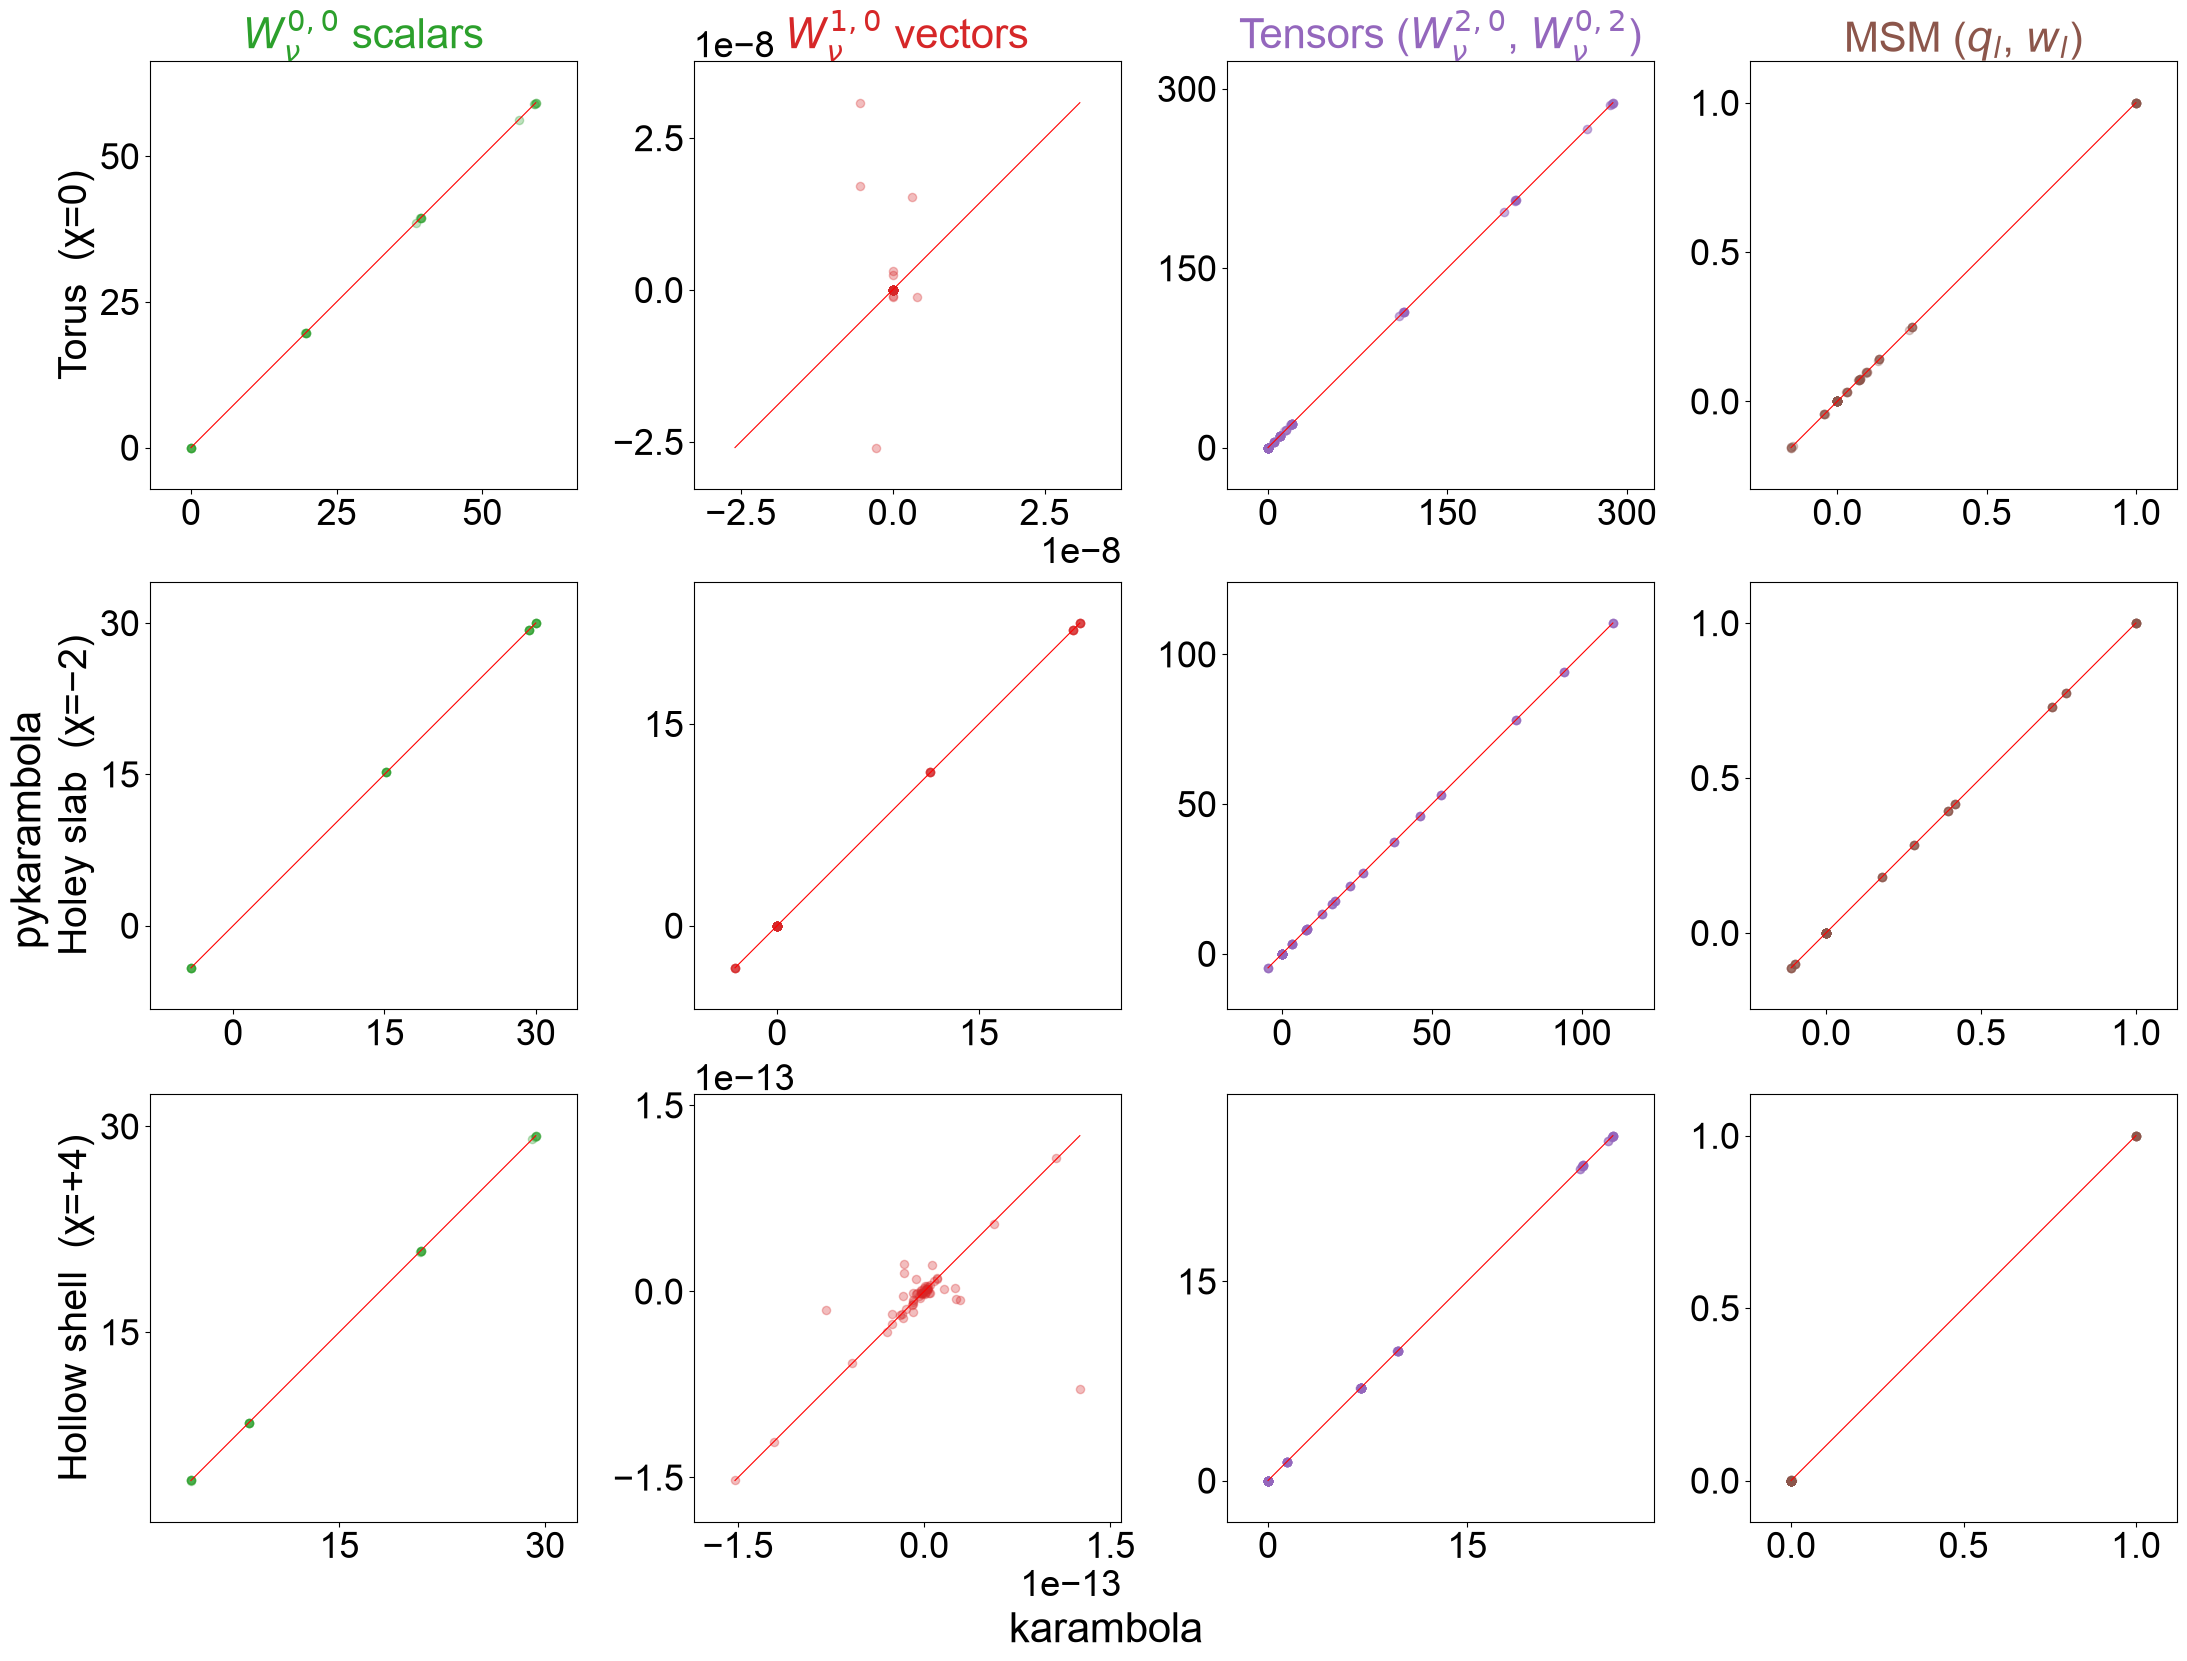

In [17]:
# ── Scatter figure: pykarambola vs karambola, one panel per feature group × shape ──
if df_k is None:
    print('Karambola results not available.')
else:
    feature_groups = [
        (r'$W_\nu^{0,0}$ scalars',
         SCALAR_KEYS),
        (r'$W_\nu^{1,0}$ vectors',
         [f'{k}_{i}' for k in VECTOR_KEYS for i in range(3)]),
        (r'Tensors ($W_\nu^{2,0}$, $W_\nu^{0,2}$)',
         [f'{k}_{i}{j}' for k in TENSOR_KEYS for i in range(3) for j in range(3)]),
        (r'MSM ($q_l$, $w_l$)',
         [f'msm_ql_{n}' for n in range(9)] + [f'msm_wl_{n}' for n in range(9)]),
    ]
    GROUP_COLORS = ['#2ca02c', '#d62728', '#9467bd', '#8c564b']

    BASE_FONT = 30
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams.update({
        'font.size':       BASE_FONT,
        'axes.titlesize':  BASE_FONT,
        'axes.labelsize':  BASE_FONT - 2,
        'xtick.labelsize': BASE_FONT - 4,
        'ytick.labelsize': BASE_FONT - 4,
        'legend.fontsize': BASE_FONT - 4,
    })

    nrows, ncols = len(SHAPES), len(feature_groups)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5.5, nrows*5.5),
                             constrained_layout=True)

    shape_labels = {'torus':        'Torus  (\u03c7=0)',
                    'holey_slab':   'Holey slab  (\u03c7=\u22122)',
                    'hollow_shell': 'Hollow shell  (\u03c7=+4)'}

    for row, shape in enumerate(SHAPES):
        subset = df_merged[df_merged['shape'] == shape]
        for col, (grp_label, features) in enumerate(feature_groups):
            ax = axes[row, col]
            k_all, py_all = [], []
            for feat in features:
                ck, cp = f'{feat}_k', f'{feat}_py'
                if ck not in subset or cp not in subset: continue
                k_all.append(subset[ck].values)
                py_all.append(subset[cp].values)
            if k_all:
                k_all  = np.concatenate(k_all)
                py_all = np.concatenate(py_all)
                ax.scatter(k_all, py_all, s=35, alpha=0.3, rasterized=True,
                           color=GROUP_COLORS[col])
                lo = min(k_all.min(), py_all.min())
                hi = max(k_all.max(), py_all.max())
                ax.plot([lo, hi], [lo, hi], 'r-', lw=0.8, zorder=5)
            ax.margins(0.12)
            ax.set_box_aspect(1)
            ax.tick_params(labelsize=BASE_FONT - 4)
            ax.xaxis.set_major_locator(plt.MaxNLocator(3))
            ax.yaxis.set_major_locator(plt.MaxNLocator(3))
            ax.xaxis.get_offset_text().set_fontsize(BASE_FONT - 4)
            ax.yaxis.get_offset_text().set_fontsize(BASE_FONT - 4)
            if row == 0:
                ax.set_title(grp_label, fontsize=BASE_FONT,
                             color=GROUP_COLORS[col])
            if col == 0:
                ax.set_ylabel(shape_labels[shape], fontsize=BASE_FONT - 2)

    fig.supxlabel('karambola', fontsize=BASE_FONT)
    fig.supylabel('pykarambola', fontsize=BASE_FONT)

    save_path = os.path.join(RESULTS_DIR, 'scatter_topology_accuracy.pdf')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f'Saved \u2192 {save_path}')
    plt.show()

## Resolution convergence

Plots key Minkowski scalars as a function of mesh resolution.
Lines for karambola and pykarambola should overlap; both should converge toward
the analytical values as resolution increases.

**Analytical values:**
- Torus (major radius R, minor radius r):  
  W₀⁰⁰⁰ = 2π²Rr²,  W₁⁰⁰⁰ = (4/3)π²Rr,  W₂⁰⁰⁰ = 2π²R/3,  **W₃⁰⁰⁰ = 0**
- Hollow shell (R_out, R_in):  
  W₀⁰⁰⁰ = (4/3)π(R_out³ − R_in³),  W₁⁰⁰⁰ = (4π/3)(R_out² + R_in²),  W₂⁰⁰⁰ = (4π/3)(R_out − R_in),  W₃⁰⁰⁰ = (2π/3)×4  (χ=4)
- Holey slab: no simple closed form for most functionals; **W₃⁰⁰⁰ = (2π/3)×(−2) = −4π/3** (χ=−2, exact)

Saved → /Users/yk/Desktop/pykarambola_m1/pykarambola/paper/notebooks/results/topology_convergence.pdf


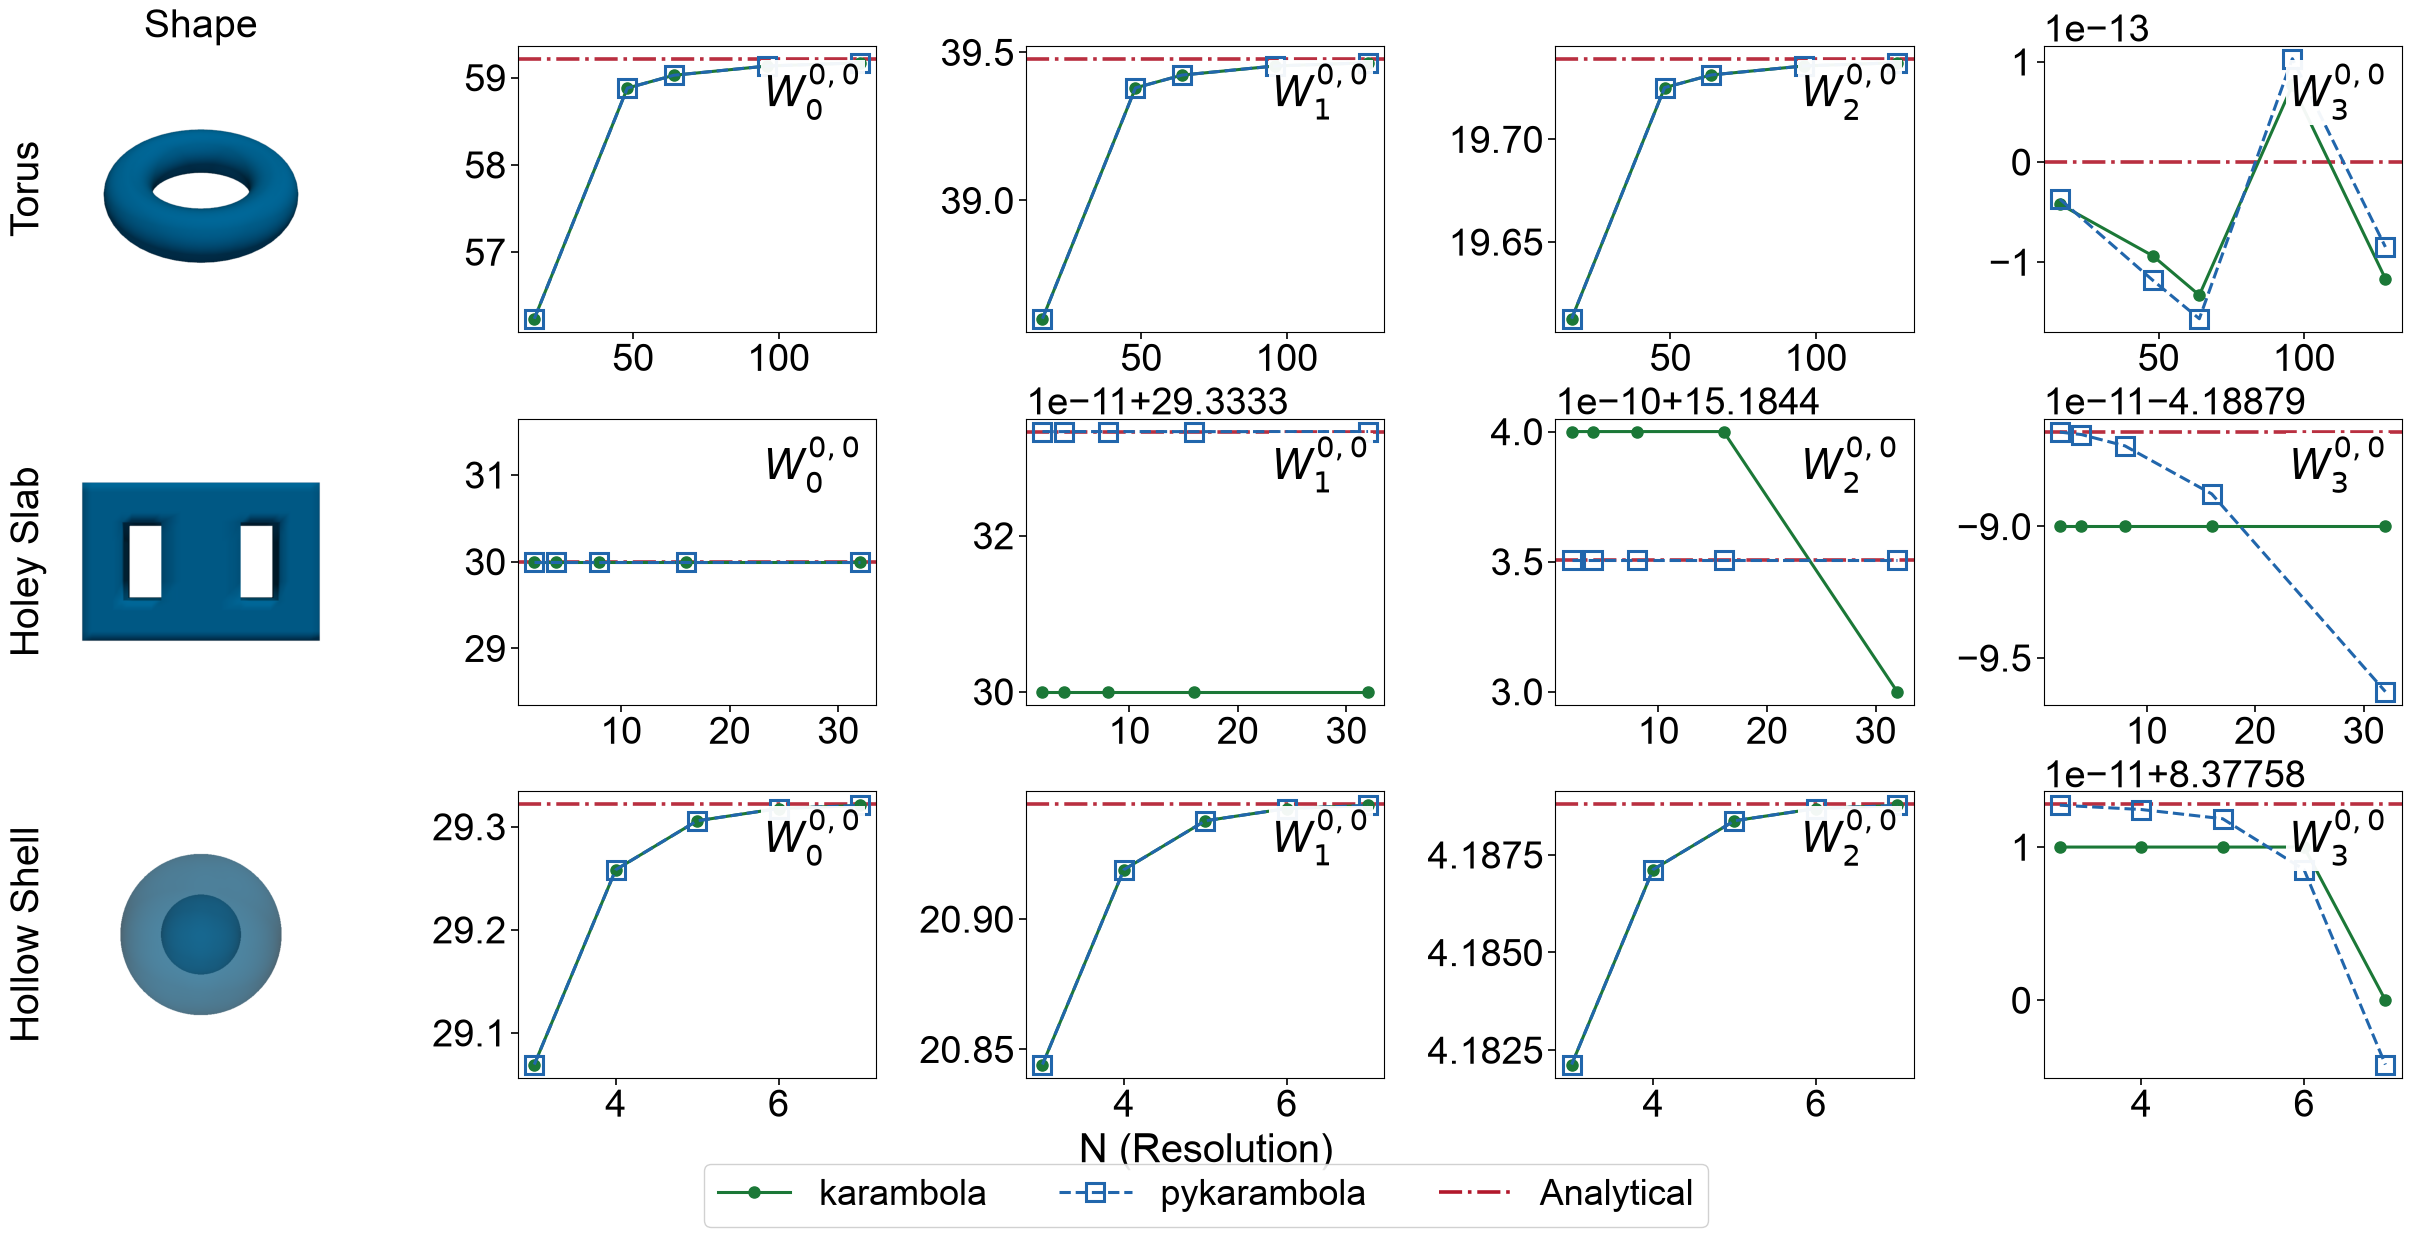

In [97]:
import re
from matplotlib.ticker import ScalarFormatter

_NUM = re.compile(r'[-+\u2212]?\d*\.?\d+(?:[eE][-+\u2212]?\d+)?')

class RoundedScalarFormatter(ScalarFormatter):
    """ScalarFormatter that rounds the offset/scale text to `sig` significant figures."""
    def __init__(self, *a, sig=6, **k):
        super().__init__(*a, **k)
        self._sig = sig
    def get_offset(self):
        s = super().get_offset()
        if not s:
            return s
        def _round(m):
            tok = m.group(0)
            v = float(tok.replace('\u2212', '-'))
            out = format(v, f'.{self._sig}g').replace('-', '\u2212')
            if tok[0] == '+' and not out.startswith('+'):
                out = '+' + out
            return out
        return _NUM.sub(_round, s)


def _n_from_id(mesh_id, shape):
    """Extract resolution parameter from mesh_id string."""
    m = re.search(r'_n(\d+)', mesh_id)
    if m:
        return int(m.group(1))
    m = re.search(r'_sub(\d+)', mesh_id)
    return int(m.group(1)) if m else None


def analytical(shape, res):
    """Analytical Minkowski scalar values for each shape.
    Returns dict {scalar: value} or {} if no closed form for this shape.
    """
    if shape == 'torus':
        R, r = TORUS_PARAMS['R'], TORUS_PARAMS['r']
        return {
            'w000': 2 * np.pi**2 * R * r**2,
            'w100': (4/3) * np.pi**2 * R * r,
            'w200': (2 * np.pi**2 * R) / 3,
            'w300': 0.0,
        }
    if shape == 'hollow_shell':
        Ro, Ri = SHELL_PARAMS['R_outer'], SHELL_PARAMS['R_inner']
        return {
            'w000': (4/3) * np.pi * (Ro**3 - Ri**3),
            'w100': (4 * np.pi / 3) * (Ro**2 + Ri**2),
            'w200': (4 * np.pi / 3) * (Ro - Ri),
            'w300': (2 * np.pi / 3) * 4,
        }
    if shape == 'holey_slab':
        x, y, z = SLAB_PARAMS['width'], SLAB_PARAMS['depth'], SLAB_PARAMS['height']
        hw, hd  = SLAB_PARAMS['hole_w'], SLAB_PARAMS['hole_d']   # <-- confirm key names
        n = 2                                                    # two through-holes (χ = -2)
        vol = x*y*z - n*z*hw*hd
        sa  = 2*(x*y + y*z + z*x) - n*2*hw*hd + n*2*z*(hw+hd)
        imc = np.pi*(x+y+z) - n*np.pi*z + n*np.pi*(hw+hd)
        return {'w000': vol, 'w100': sa/3, 'w200': imc/3, 'w300': (2*np.pi/3)*(-2)}


SCALAR_LATEX = {'w000': r'$W_0^{0,0}$', 'w100': r'$W_1^{0,0}$',
                'w200': r'$W_2^{0,0}$', 'w300': r'$W_3^{0,0}$'}
C_K, C_PY, C_AN = '#1b7837', '#2166ac', '#b2182b'   # karambola / pykarambola / analytical

if df_k is not None:
    from matplotlib.lines import Line2D
    BASE_FONT = 28
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams.update({'font.size': BASE_FONT, 'axes.titlesize': BASE_FONT,
                         'axes.labelsize': BASE_FONT, 'xtick.labelsize': BASE_FONT-1,
                         'ytick.labelsize': BASE_FONT-1, 'legend.fontsize': BASE_FONT-3})

    fig = plt.figure(figsize=(24, len(SHAPES)*3.9), constrained_layout=True)
    gs  = fig.add_gridspec(len(SHAPES), 5, width_ratios=[1.05, 1, 1, 1, 1])  # preview + 4 scalars
    fig.get_layout_engine().set(wspace=0.09)

    for row, shape in enumerate(SHAPES):
        subset_k = df_merged[df_merged['shape'] == shape].copy()
        subset_k['_res'] = subset_k['mesh_id'].apply(lambda x: _n_from_id(x, shape))
        subset_k = subset_k.sort_values('_res')
        an = analytical(shape, None)
        x  = subset_k['_res']

        # --- column 0: shape preview ---
        axp = fig.add_subplot(gs[row, 0])
        axp.imshow(plt.imread(SHAPE_SNAPSHOTS[shape]))
        axp.set_axis_off()
        axp.text(-0.04, 0.5, shape.replace('_', ' ').title(), transform=axp.transAxes,
                 rotation=90, va='center', ha='right', fontsize=BASE_FONT)
        if row == 0:
            axp.set_title('Shape', fontsize=BASE_FONT)

        # --- columns 1–4: the scalar convergence plots ---
        for col, key in enumerate(SCALAR_KEYS):
            ax = fig.add_subplot(gs[row, col + 1])
            if key in an:
                ax.axhline(an[key], color=C_AN, ls='-.', lw=2.6, alpha=0.9, zorder=1)
            ax.plot(x, subset_k[f'{key}_k'],  '-',  marker='o', ms=8,  lw=2.2,
                    color=C_K, zorder=2)
            ax.plot(x, subset_k[f'{key}_py'], '--', marker='s', ms=13, lw=2.2,
                    color=C_PY, mfc='none', mec=C_PY, mew=2.2, zorder=3)
            ax.tick_params(axis='both', labelsize=BASE_FONT-1, length=5, width=1.2)
            f = RoundedScalarFormatter(useMathText=False, sig=6); f.set_useOffset(True)
            ax.yaxis.set_major_formatter(f)
            ax.text(0.96, 0.94, SCALAR_LATEX[key], transform=ax.transAxes, ha='right', va='top',
                    fontsize=BASE_FONT+2, bbox=dict(facecolor='white', alpha=0.95, edgecolor='none', pad=2))

    fig.supxlabel('n (resolution)'.title(), fontsize=BASE_FONT+1)
    handles = [Line2D([0],[0],color=C_K,  marker='o', ms=8,  lw=2.2, label='karambola'),
               Line2D([0],[0],color=C_PY, marker='s', ms=13, lw=2.2, ls='--', mfc='none', mew=2.2, label='pykarambola'),
               Line2D([0],[0],color=C_AN, ls='-.', lw=2.6, label='Analytical')]
    fig.legend(handles=handles, loc='lower center', ncol=3, framealpha=0.9,
               fontsize=BASE_FONT-2, bbox_to_anchor=(0.5, -0.06))
    save_path = os.path.join(RESULTS_DIR, 'topology_convergence.pdf')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f'Saved → {save_path}'); plt.show()
else:
    print('Karambola results not available — skipping convergence plot.')